# The multi-regional RNN model of fixation-aligned activity — where the analysis stands

*A stock-take, not a chapter.* It reads every fitted network in the scratch tree, scores
them on one footing, and separates what the fits establish from what they only suggest.
The last two sections say what has to be run before any of it can be written up.

| Section | Question |
|---|---|
| 1 | What has actually been fitted, and which fits are comparable? |
| 2 | How many units per region do we need? |
| 3 | Which regional connectivity does the data require? |
| 4 | How narrow can inter-regional communication be? |
| 5 | Do independent fits find the same circuit? |
| 6 | What *is* invariant across fits? |
| 7 | Is the low-rank channel itself invariant? |
| 8 | What we can infer |
| 9 | What still has to be tested |

The companion audit, with the run-by-run detail and the gap list in prose, is
[`README.md`](README.md). The exploratory notebooks these fits came from are the loose
`fixation_mrnn_*.ipynb` files in [`../`](..).

**The model.** An Elman multi-regional RNN with one 50-unit block per region
(OFC, BLA, dmPFC, ACCg). Input is the three fixation-condition one-hot channels and
nothing else, so all temporal structure has to come from the recurrent dynamics. Each
region reads out linearly to its own 42 principal components of normalised firing rate
— the smallest shared count that reaches 95% variance in every region. The target is
3 conditions x 100 bins (10 ms, −500…+500 ms) x 4 regions x 42 PCs = 50,400 numbers.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = next(parent for parent in Path.cwd().parents if (parent / "src").exists())
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from dal_monte_2022_analysis.config.load import load_config
from dal_monte_2022_analysis.ephys.analysis import fixation_mrnn_synthesis as syn
from dal_monte_2022_analysis.ephys.plotting import fixation_mrnn_synthesis as viz
from dal_monte_2022_analysis.ephys.plotting.thesis_common import (
    ThesisFigureSettings,
    apply_thesis_plot_style,
    figure_to_png_bytes,
    save_thesis_figure,
)

DATASET_CFG_PATH = repo_root / "configs" / "dataset.yaml"
PLOTTING_CFG_PATH = repo_root / "configs" / "plotting.yaml"
apply_thesis_plot_style(load_config(PLOTTING_CFG_PATH))

SCRATCH_ROOT = syn.resolve_scratch_root(DATASET_CFG_PATH)
FIGURE_DIR = syn.resolve_output_dir(DATASET_CFG_PATH, scope="synthesis")
FIGURES = ThesisFigureSettings(output_dir=FIGURE_DIR)

#: The three ensembles the consistency results rest on.
ENSEMBLE_100_SEED = SCRATCH_ROOT / "ensemble_d5_c3_50u_100k_100init"
ENSEMBLE_RANK_1 = SCRATCH_ROOT / "bottleneck1d_l1within_50u_100k_10init"
ENSEMBLE_RANK_3 = SCRATCH_ROOT / "bottleneck3d_l1within_50u_250k_10init"


def show(figure, stem: str) -> None:
    """Write one figure as editable PDF plus PNG, then display it inline."""
    save_thesis_figure(figure, FIGURES, stem)
    display(Image(data=figure_to_png_bytes(figure, dpi=190)))


print("scratch tree:", SCRATCH_ROOT)
print("figures ->  ", FIGURE_DIR)

scratch tree: /gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/modeling/fixation_mrnn/scratch
figures ->   /gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/modeling/fixation_mrnn/plots/synthesis


## 1. What has actually been fitted

Every run directory carries the exact `settings` and `model_spec` it was trained with,
so the inventory below is the *trained* configuration rather than a re-derivation from
the current config file. Two things are read from the loss history rather than from the
settings, because in several runs the two disagree:

- **iterations actually completed**, not the requested `epochs`;
- **the best loss reached**, against the final loss that was checkpointed.

In [2]:
inventory = syn.index_fixation_mrnn_runs(SCRATCH_ROOT)
family_summary = syn.summarize_run_families(inventory)

n_experiments = int((inventory["ensemble"] == "").sum())
n_ensemble_members = int((inventory["ensemble"] != "").sum())
display(Markdown(
    f"**{len(inventory)} fitted networks**: {n_experiments} standalone experiments plus "
    f"{n_ensemble_members} members across {inventory.loc[inventory['ensemble'] != '', 'ensemble'].nunique()} "
    f"multi-initialization ensembles."
))
display(family_summary)

**273 fitted networks**: 54 standalone experiments plus 219 members across 4 multi-initialization ensembles.

,family,n_runs,epochs,hidden_units,activation,lr,l1_weight_scale,recurrent_bottleneck_dim
0,seed ensemble,199,100000,50,softplus,0.001,0.0,None
1,bottleneck ensemble,20,"100000, 250000",50,tanh,0.0003,0.01,"1.0, 3.0"
2,loss sweep,14,"15000, 20000, 25000","40, 50",softplus,"0.0001, 0.0003, 0.001, 0.002, 0.005, 0.01",0.0,None
3,smoke test,8,"10000, 2","50, 8",softplus,0.001,"0.0, 0.0001",None
4,bottleneck sweep,8,"100000, 50000",50,tanh,0.0003,0.01,"1.0, 10.0, 2.0, 20.0, 3.0, 30.0, 4.0, 5.0"
5,loss necessity,8,"100000, 20000, 50000",50,softplus,0.001,0.0,None
6,hidden-unit sweep,8,"10000, 20000, 25000","10, 20, 25, 30, 40, 5, 50, 60",softplus,"0.0001, 0.0003, 0.001",0.0,None
7,architecture comparison,6,50000,"40, 50",tanh,0.0003,0.0,None
8,current geometry,2,100000,50,"softplus, tanh",0.001,0.0,None


### 1a. Two bookkeeping problems that affect every comparison downstream

Both are properties of the saved runs, not of the analysis, and both have to be fixed
before any of these fits can be compared in a chapter.

In [3]:
misnamed = syn.flag_run_name_iteration_mismatch(inventory)

not_best = inventory[inventory["final_over_best"] > 1.5]
worst = inventory.nlargest(5, "final_over_best")[["run", "final_over_best", "final_iteration"]]

display(Markdown(
    f"**Checkpoints are the final iterate, not the best one.** "
    f"{len(not_best)} of {len(inventory)} saved checkpoints "
    f"({100 * len(not_best) / len(inventory):.0f}%) sit more than 1.5x above the lowest loss their own "
    f"run reached. A worse fit is only evidence about an architecture if the checkpoint is the "
    f"model the run actually found.\n\n"
    f"**{len(misnamed)} run directories are named for an iteration count they never reached.** "
    f"Any comparison keyed on the directory name inherits that error."
))
display(misnamed)
display(worst.round(2))

**Checkpoints are the final iterate, not the best one.** 89 of 273 saved checkpoints (33%) sit more than 1.5x above the lowest loss their own run reached. A worse fit is only evidence about an architecture if the checkpoint is the model the run actually found.

**2 run directories are named for an iteration count they never reached.** Any comparison keyed on the directory name inherits that error.

,run,name_claims_iterations,actual_iterations
0,loss_necessity_pc_deriv_curv_50u_200k_pc_deriv...,200000,20000
1,loss_necessity_pc_deriv_curv_50u_200k_pc_deriv...,200000,20000


,run,final_over_best,final_iteration
45,ensemble_d5_c3_50u_100k_100init/init=009_seed=...,1.373673e+25,100000.0
248,loss_necessity_pc_deriv_curv_50u_200k_pc_deriv...,4.906633e+19,20000.0
127,ensemble_d5_c3_50u_100k_100init/init=091_seed=...,8.202911e+05,100000.0
130,ensemble_d5_c3_50u_100k_100init/init=094_seed=...,2.681329e+05,100000.0
107,ensemble_d5_c3_50u_100k_100init/init=071_seed=...,2.508000e+03,100000.0


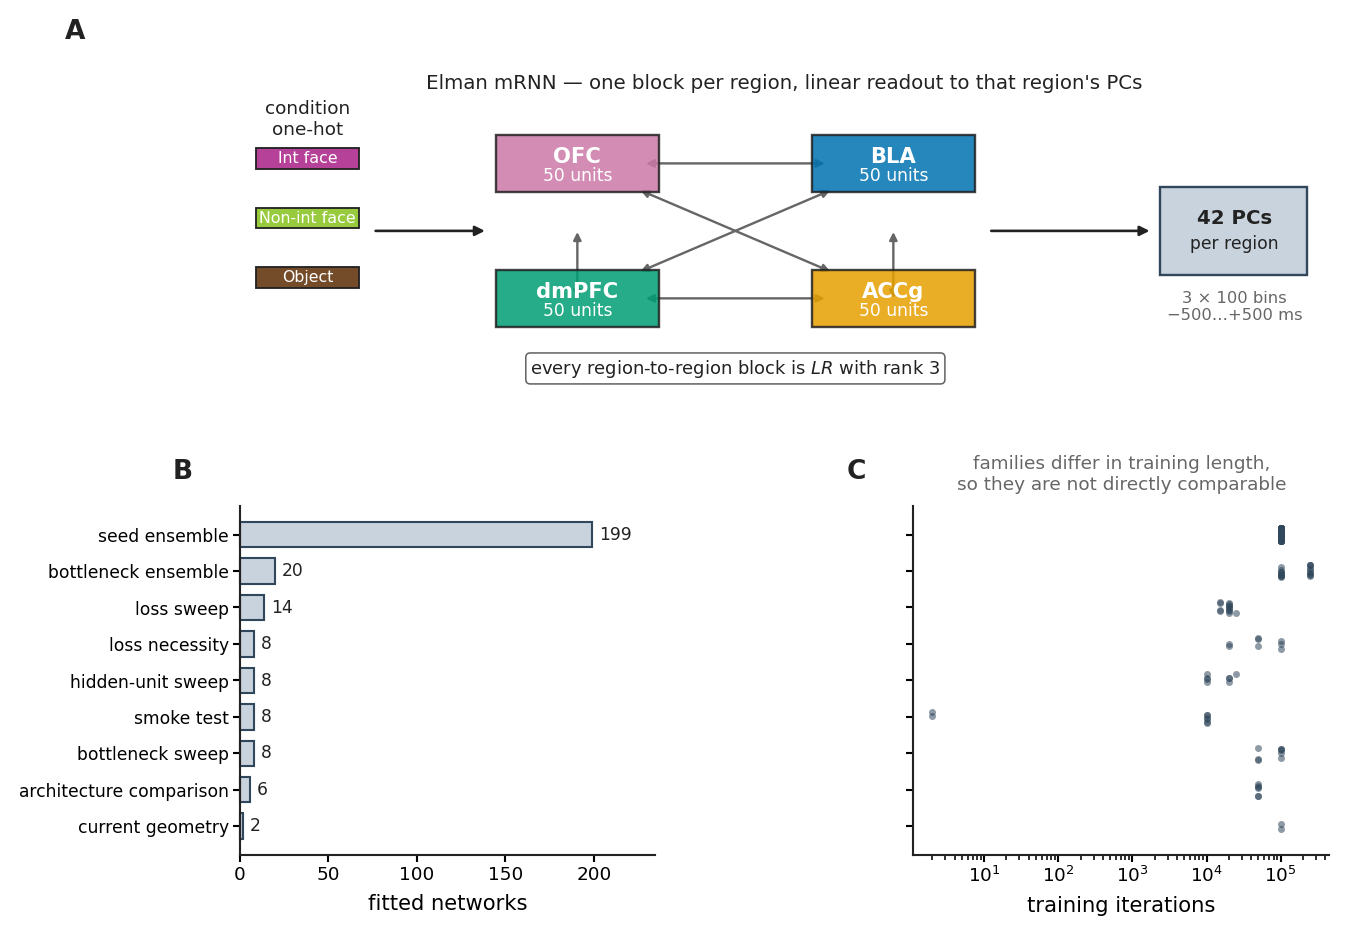

In [4]:
show(viz.plot_run_inventory(family_summary, inventory), "fig01_model_and_inventory")

**Figure 1.** (A) The model. (B) How many networks were fitted per experiment family.
(C) Training length per family, on a log axis. Panel C is the reason nothing in this
notebook is plotted as one curve across families: they differ in iterations, learning
rate, activation, L1 penalty and loss weights, and only comparisons made *within* a
family hold those fixed.

## 2. How many units per region?

This was the first question the project asked, and it is the one place where the answer
has to be withdrawn. The hidden-unit sweep varied width — but it also varied the
learning rate, and in the wrong direction: the widest models were trained with the
smallest step size.

,hidden_units,lr,final_iteration,mean_r2
0,5,0.0010,10000.0,-5.021737e+21
1,10,0.0010,10000.0,1.530000e-01
2,20,0.0010,25000.0,5.536000e-01
3,25,0.0010,10000.0,6.142000e-01
4,30,0.0003,10000.0,6.939000e-01
5,40,0.0001,20000.0,8.173000e-01
6,50,0.0001,20000.0,8.151000e-01
7,60,0.0001,20000.0,8.763000e-01


,run,lr,final_iteration,mean_r2
11,hidden_unit_sweep_region_pcs_condition_only_h050,0.0001,20000.0,8.151000e-01
1,bottleneck_dim_10,0.0003,50000.0,9.494000e-01
3,bottleneck_dim_20,0.0003,50000.0,8.070000e-01
5,bottleneck_dim_30,0.0003,50000.0,9.398000e-01
8,cca_42pc_tanh_h50_cross_region_with_self_diagonal,0.0003,50000.0,9.926000e-01
9,cca_42pc_tanh_h50_full,0.0003,50000.0,9.954000e-01
10,cca_42pc_tanh_h50_within_region,0.0003,50000.0,9.500000e-01
0,bottleneck_dim_1,0.0003,100000.0,9.659000e-01
2,bottleneck_dim_2,0.0003,100000.0,9.659000e-01
4,bottleneck_dim_3,0.0003,100000.0,9.776000e-01


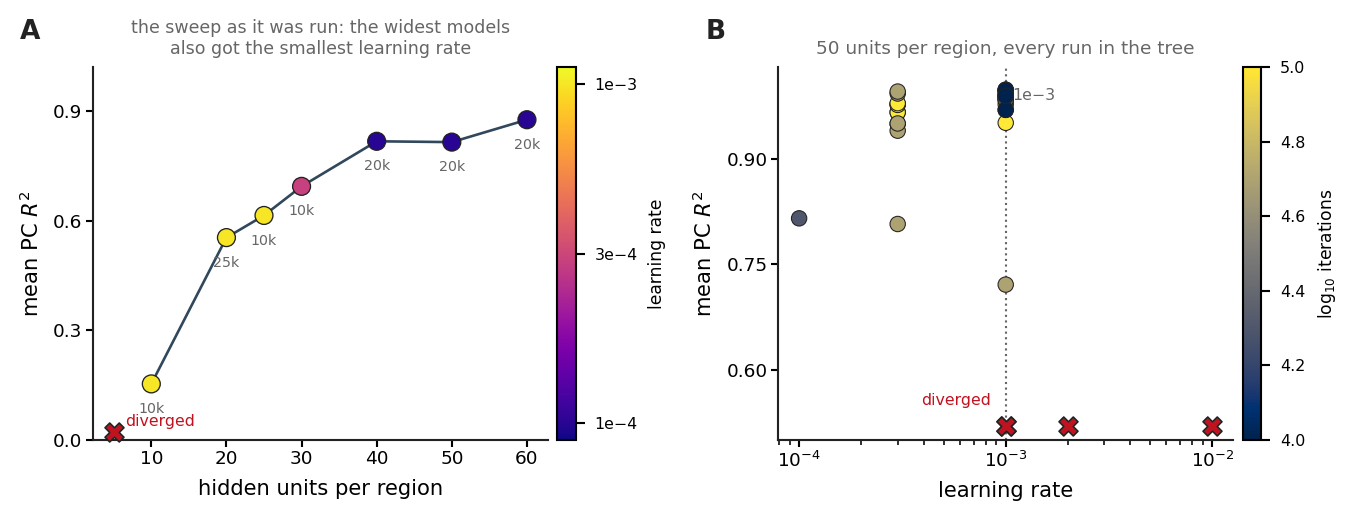

In [5]:
sweep_rows = []
for _, run in inventory[inventory["family"] == "hidden-unit sweep"].iterrows():
    quality = syn.run_fit_quality(run["run_dir"])
    sweep_rows.append({
        "hidden_units": run["hidden_units"],
        "lr": run["lr"],
        "final_iteration": run["final_iteration"],
        "mean_r2": quality.loc[quality["space"] == "pc", "r2"].mean(),
    })
hidden_sweep = pd.DataFrame(sweep_rows).sort_values("hidden_units").reset_index(drop=True)

fifty_unit = inventory[(inventory["hidden_units"] == 50) & (inventory["ensemble"] == "")]
fifty_rows = []
for _, run in fifty_unit.iterrows():
    quality = syn.run_fit_quality(run["run_dir"])
    fifty_rows.append({
        "run": run["run"],
        "lr": run["lr"],
        "final_iteration": run["final_iteration"],
        "mean_r2": quality.loc[quality["space"] == "pc", "r2"].mean(),
    })
fifty_unit_runs = pd.DataFrame(fifty_rows)

display(hidden_sweep.round(4))
display(fifty_unit_runs.sort_values(["lr", "final_iteration"]).round(4))
show(viz.plot_capacity_vs_learning_rate(hidden_sweep, fifty_unit_runs), "fig02_capacity_confound")

In [6]:
# Diverged runs score arbitrarily large negative R^2; they are counted separately
# rather than averaged in.
usable = fifty_unit_runs[np.isfinite(fifty_unit_runs["mean_r2"]) & (fifty_unit_runs["mean_r2"] > 0)]
diverged = fifty_unit_runs.drop(index=usable.index)
matched = usable[usable["final_iteration"] == 20000]
diverged_rates = sorted({float(v) for v in diverged["lr"]})
low_lr = float(hidden_sweep.loc[hidden_sweep["hidden_units"] == 50, "mean_r2"].iloc[0])
high_lr = matched.loc[matched["lr"] == 1e-3, "mean_r2"]

display(Markdown(
    f"At **50 units per region and 20,000 iterations** — width and training length both held "
    f"fixed — a learning rate of 1e-4 reaches mean PC $R^2$ **{low_lr:.3f}**, while a learning rate "
    f"of 1e-3 reaches **{high_lr.mean():.3f}** (n = {len(high_lr)} runs, "
    f"{high_lr.min():.3f}–{high_lr.max():.3f}). The entire apparent capacity effect in the sweep "
    f"is the learning rate.\n\n"
    f"The step size cannot simply be raised, though: {len(diverged)} of the {len(fifty_unit_runs)} "
    f"50-unit runs in the tree diverged, at learning rates "
    + ", ".join(f"{rate:g}" for rate in diverged_rates)
    + f". Divergence is not confined to the large steps — 1e-3 is a working band rather than a safe "
    f"one, which is the same fragility Section 5 quantifies as a seed failure rate.\n\n"
    f"**The sweep therefore does not answer its own question.** What it does establish is that "
    f"50 units per region is *sufficient*: at a working learning rate, 50-unit models reach "
    f"$R^2$ above 0.98. Whether 20 or 30 would also suffice has not been tested — every model "
    f"below 40 units was trained under different settings."
))

At **50 units per region and 20,000 iterations** — width and training length both held fixed — a learning rate of 1e-4 reaches mean PC $R^2$ **0.815**, while a learning rate of 1e-3 reaches **0.985** (n = 4 runs, 0.983–0.987). The entire apparent capacity effect in the sweep is the learning rate.

The step size cannot simply be raised, though: 4 of the 34 50-unit runs in the tree diverged, at learning rates 0.001, 0.002, 0.01. Divergence is not confined to the large steps — 1e-3 is a working band rather than a safe one, which is the same fragility Section 5 quantifies as a seed failure rate.

**The sweep therefore does not answer its own question.** What it does establish is that 50 units per region is *sufficient*: at a working learning rate, 50-unit models reach $R^2$ above 0.98. Whether 20 or 30 would also suffice has not been tested — every model below 40 units was trained under different settings.

## 3. Which regional connectivity does the data require?

Three architectures, 50 units per region, 50,000 iterations, one seed each:

- **full** — every region-to-region recurrent block is free;
- **cross-region + self-diagonal** — cross-region blocks, plus only a diagonal inside each region;
- **within-region only** — each region's internal block, and no coupling at all.

These three share every setting except connectivity, so this comparison is internally
clean. What it cannot separate is architecture from parameter count: `within_region`
carries about 40% of `full`'s parameters.

,label,mean_r2,median_r2,min_r2,n_cells
0,cross_region_with_self_diagonal,0.9926,0.9950,0.9739,12
1,full,0.9954,0.9973,0.9828,12
2,within_region,0.9500,0.9819,0.7391,12


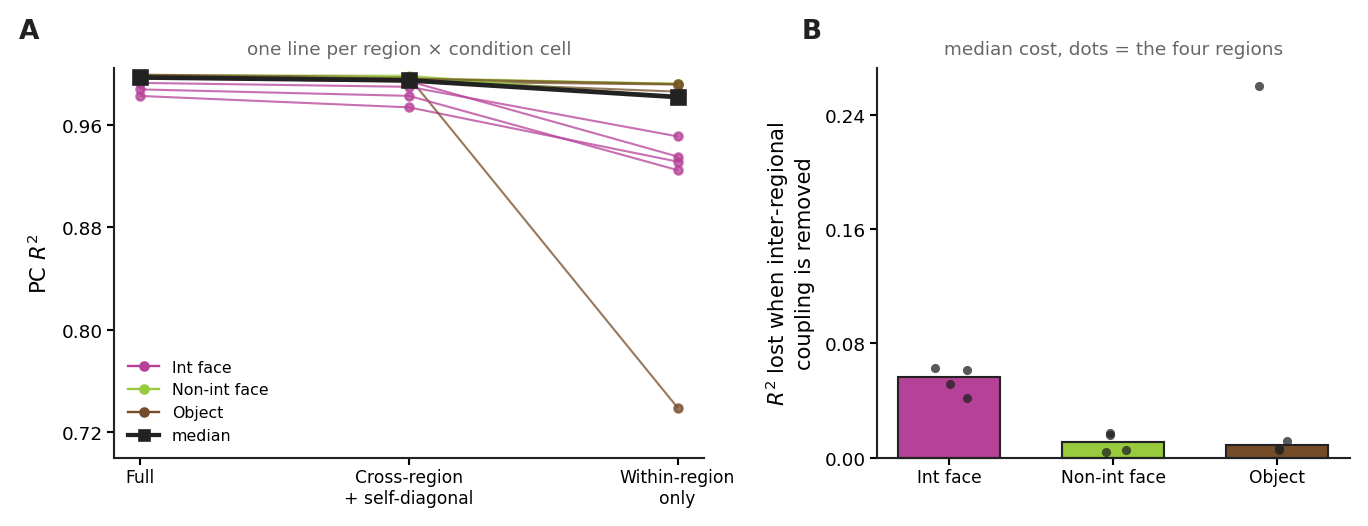

In [7]:
architecture_runs = {
    run["run"].replace("cca_42pc_tanh_h50_", ""): run["run_dir"]
    for _, run in inventory[
        (inventory["family"] == "architecture comparison") & (inventory["hidden_units"] == 50)
    ].iterrows()
}
architecture_quality = syn.collect_fit_quality(architecture_runs)
architecture_cells = (
    architecture_quality[architecture_quality["space"] == "pc"]
    .pivot_table(index=["region", "condition"], columns="label", values="r2")
    .reset_index()
)

display(syn.pooled_r2(architecture_quality).round(4))
show(viz.plot_architecture_comparison(architecture_cells), "fig03_architecture")

In [8]:
cost = architecture_cells.assign(cost=architecture_cells["full"] - architecture_cells["within_region"])
by_condition = cost.groupby("condition")["cost"].median()
ratio = by_condition["face_interactive"] / by_condition[["face_non_interactive", "object"]].mean()

display(Markdown(
    f"**Inter-regional coupling is required; dense internal recurrence is not.** Dropping "
    f"cross-region blocks costs "
    f"{architecture_cells['full'].mean() - architecture_cells['within_region'].mean():.3f} in mean "
    f"$R^2$; reducing internal coupling to a diagonal costs "
    f"{architecture_cells['full'].mean() - architecture_cells['cross_region_with_self_diagonal'].mean():.3f}. "
    f"All twelve region x condition cells order the three architectures identically.\n\n"
    f"**And the coupling is for interactive face fixations.** Removing it costs a median "
    f"{by_condition['face_interactive']:.3f} $R^2$ during interactive face fixations against "
    f"{by_condition['face_non_interactive']:.3f} (non-interactive face) and "
    f"{by_condition['object']:.3f} (object) — a factor of **{ratio:.1f}**. Interactive face is also "
    f"the hardest condition for the intact model. With one seed per architecture this is a "
    f"description of these three fits, not an inferential claim."
))
display(cost.pivot_table(index="condition", values="cost", aggfunc=["median", "mean", "min", "max"]).round(4))

**Inter-regional coupling is required; dense internal recurrence is not.** Dropping cross-region blocks costs 0.045 in mean $R^2$; reducing internal coupling to a diagonal costs 0.003. All twelve region x condition cells order the three architectures identically.

**And the coupling is for interactive face fixations.** Removing it costs a median 0.056 $R^2$ during interactive face fixations against 0.011 (non-interactive face) and 0.009 (object) — a factor of **5.6**. Interactive face is also the hardest condition for the intact model. With one seed per architecture this is a description of these three fits, not an inferential claim.

,median,mean,min,max
label,cost,cost,cost,cost
condition,,,,
face_interactive,0.0563,0.0544,0.0418,0.0631
face_non_interactive,0.0108,0.0108,0.0043,0.0172
object,0.0092,0.0710,0.0052,0.2603


## 4. How narrow can inter-regional communication be?

Each inter-regional block is constrained to rank $r$ by writing it as $LR$, so all
communication between a pair of regions passes through $r$ dimensions. The sweep splits
into an epoch-matched block (ranks 1–5, 100,000 iterations) and a shorter block
(ranks 10–30, 50,000 iterations) that cannot be read against it.

region                   accg     bla   dmpfc     ofc
epochs bottleneck_dim                                
50000  10              0.9347  0.9707  0.9417  0.9506
       20              0.7652  0.8309  0.8193  0.8127
       30              0.9148  0.9557  0.9412  0.9473
100000 1               0.9471  0.9863  0.9571  0.9733
       2               0.9475  0.9846  0.9585  0.9727
       3               0.9684  0.9891  0.9717  0.9811
       4               0.9645  0.9885  0.9732  0.9795
       5               0.9696  0.9885  0.9756  0.9819

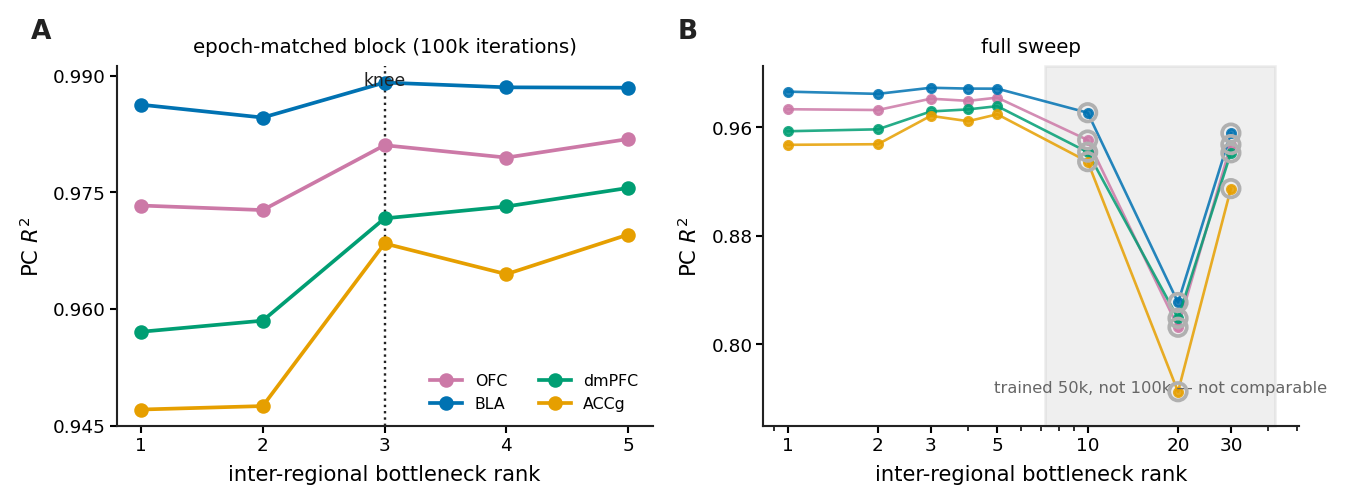

In [9]:
bottleneck_frames = []
for _, run in inventory[inventory["family"] == "bottleneck sweep"].iterrows():
    quality = syn.run_fit_quality(run["run_dir"])
    summary = quality.groupby(["region", "space"])["r2"].mean().reset_index()
    summary["bottleneck_dim"] = int(run["recurrent_bottleneck_dim"])
    summary["epochs"] = int(run["final_iteration"])
    bottleneck_frames.append(summary)
bottleneck = pd.concat(bottleneck_frames, ignore_index=True)

display(
    bottleneck[bottleneck["space"] == "pc"]
    .pivot_table(index=["epochs", "bottleneck_dim"], columns="region", values="r2")
    .round(4)
)
show(viz.plot_bottleneck_sweep(bottleneck), "fig04_bottleneck")

In [10]:
matched_block = bottleneck[(bottleneck["epochs"] == 100000) & (bottleneck["space"] == "pc")]
per_rank = matched_block.groupby("bottleneck_dim")["r2"].mean()
fr_floor = bottleneck.loc[bottleneck["space"] == "fr", "r2"].min()

display(Markdown(
    f"**Rank 3 is the knee.** Mean PC $R^2$ across regions runs "
    + ", ".join(f"{int(r)}: {v:.3f}" for r, v in per_rank.items())
    + f". Going from rank 1 to rank 3 buys {per_rank[3] - per_rank[1]:.3f}; going from 3 to 5 buys "
    f"{per_rank[5] - per_rank[3]:.3f}.\n\n"
    f"**And in firing-rate space none of it is visible**: every run in the sweep, at every rank, "
    f"reconstructs the PC-backprojected firing rates at $R^2 \\geq$ {fr_floor:.3f}. The PC-space "
    f"differences live in components that carry almost no firing-rate variance, which is worth "
    f"holding onto before treating a 0.02 $R^2$ gap as a mechanistic fact.\n\n"
    f"**The unconstrained model did not discover this.** The `full` architecture in Section 3 left "
    f"every inter-regional block numerically full rank, spreading 90% of its energy over roughly "
    f"half the available directions. An unpenalised optimiser has no reason to concentrate a block, "
    f"so the broad spectrum was slack, not signal — which is exactly what an explicit rank-3 "
    f"constraint reaching the same quality demonstrates."
))

**Rank 3 is the knee.** Mean PC $R^2$ across regions runs 1: 0.966, 2: 0.966, 3: 0.978, 4: 0.976, 5: 0.979. Going from rank 1 to rank 3 buys 0.012; going from 3 to 5 buys 0.001.

**And in firing-rate space none of it is visible**: every run in the sweep, at every rank, reconstructs the PC-backprojected firing rates at $R^2 \geq$ 0.993. The PC-space differences live in components that carry almost no firing-rate variance, which is worth holding onto before treating a 0.02 $R^2$ gap as a mechanistic fact.

**The unconstrained model did not discover this.** The `full` architecture in Section 3 left every inter-regional block numerically full rank, spreading 90% of its energy over roughly half the available directions. An unpenalised optimiser has no reason to concentrate a block, so the broad spectrum was slack, not signal — which is exactly what an explicit rank-3 constraint reaching the same quality demonstrates.

## 5. Do independent fits find the same circuit?

This is where the modelling programme currently stops. Two questions, and they have
different answers: whether the *fit* replicates, and whether the *circuit read off the
fit* replicates.

Consistency is measured on summaries that are invariant to permutation and sign of
hidden units, because those are arbitrary across initializations: the magnitude of each
source→target current, each source's relative contribution to its target's drive, and
the representational dissimilarity matrix of the recurrent drive. The score is the mean
off-diagonal correlation over initializations; 1 would mean every seed found the same
dynamics.

ensemble,rank-1 bottleneck (100k iter),rank-3 bottleneck (250k iter)
metric_family,,
geometry RSA — accg,0.298,0.370
geometry RSA — bla,0.435,0.430
geometry RSA — dmpfc,0.304,0.416
geometry RSA — ofc,0.364,0.417
inter-regional current magnitude,0.202,0.599
latent geometry (drive RDM / RSA),0.350,0.408
relative source contribution,0.081,0.354


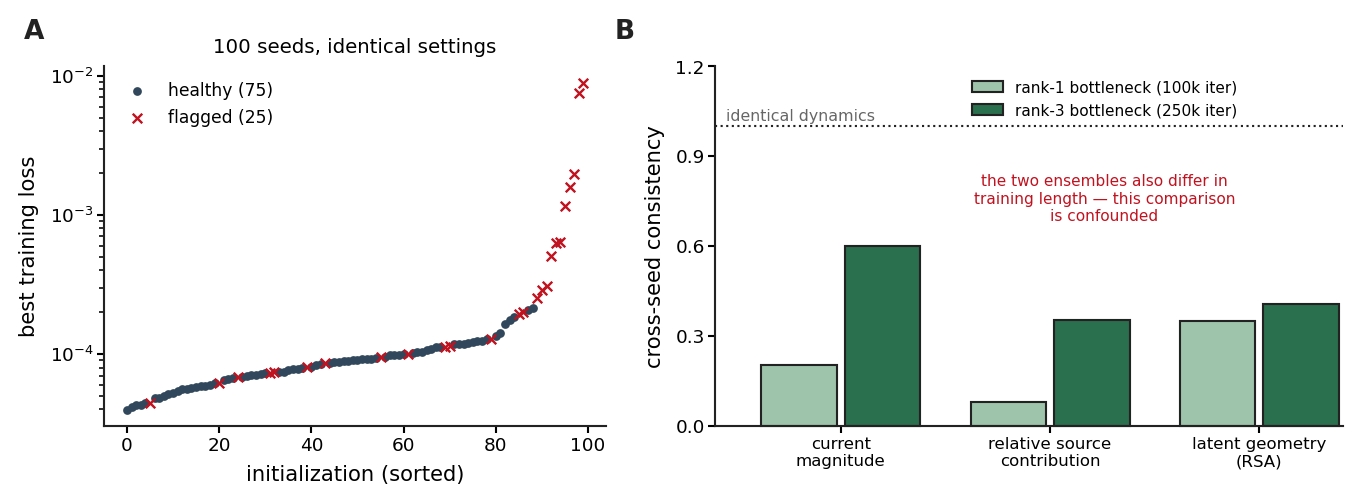

In [11]:
health = syn.load_ensemble_training_health(ENSEMBLE_100_SEED)
consistency = syn.load_ensemble_consistency({
    "rank-1 bottleneck (100k iter)": ENSEMBLE_RANK_1,
    "rank-3 bottleneck (250k iter)": ENSEMBLE_RANK_3,
})

display(consistency.pivot_table(index="metric_family", columns="ensemble", values="consistency_score").round(3))
show(viz.plot_reproducibility(health, consistency), "fig05_reproducibility")

In [12]:
n_bad = int(health["likely_bad_run"].sum())
healthy = health[~health["likely_bad_run"].astype(bool)]
spread = healthy["min_loss"].max() / healthy["min_loss"].min()
rank3 = consistency[consistency["ensemble"].str.startswith("rank-3")].set_index("metric_family")["consistency_score"]

display(Markdown(
    f"**A quarter of seeds fail outright.** {n_bad} of {len(health)} initializations of the same "
    f"model at the same settings are flagged for divergence or failure to improve. Among the "
    f"{len(healthy)} that survive, the best loss spans a factor of {spread:.0f}.\n\n"
    f"**The survivors do not agree on the circuit.** Even the best case — the rank-3 bottleneck — "
    f"reaches only {rank3['inter-regional current magnitude']:.2f} on current magnitude, "
    f"{rank3['relative source contribution']:.2f} on relative source contribution and "
    f"{rank3['latent geometry (drive RDM / RSA)']:.2f} on latent geometry. Models that fit the same "
    f"data equally well route the drive differently.\n\n"
    f"**The rank-1 versus rank-3 comparison is confounded** and must not be reported as it stands: "
    f"the two ensembles differ in training length (100k against 250k iterations) as well as in rank. "
    f"That the bottleneck raises consistency is a plausible reading of the numbers, not a result."
))

**A quarter of seeds fail outright.** 25 of 100 initializations of the same model at the same settings are flagged for divergence or failure to improve. Among the 75 that survive, the best loss spans a factor of 5.

**The survivors do not agree on the circuit.** Even the best case — the rank-3 bottleneck — reaches only 0.60 on current magnitude, 0.35 on relative source contribution and 0.41 on latent geometry. Models that fit the same data equally well route the drive differently.

**The rank-1 versus rank-3 comparison is confounded** and must not be reported as it stands: the two ensembles differ in training length (100k against 250k iterations) as well as in rank. That the bottleneck raises consistency is a plausible reading of the numbers, not a result.

## 6. What *is* invariant across fits?

Given Section 5, the useful question is not what one fitted network does but what every
fitted network does. The 100-seed ensemble answers it. Each seed contributes one
time-averaged drive share per source region and condition, so the condition comparison
is **paired within a seed** — the same network is asked about all three conditions. That
pairing is what makes the test meaningful despite the large seed-to-seed spread in the
absolute share.

Only the 75 seeds that passed the training-health check are used.

,source_region,condition_a,condition_b,mean_a,mean_b,difference,n_seeds,wilcoxon_w,p_raw,p_holm
0,accg,face_interactive,face_non_interactive,0.25940,0.26427,-0.00487,75,1253.0,0.36374,1.00000
1,accg,face_interactive,object,0.25940,0.25278,0.00662,75,1270.0,0.41308,1.00000
2,accg,face_non_interactive,object,0.26427,0.25278,0.01149,75,1170.0,0.17813,1.00000
3,bla,face_interactive,face_non_interactive,0.24710,0.28058,-0.03348,75,432.0,0.00000,0.00000
4,bla,face_interactive,object,0.24710,0.28112,-0.03401,75,695.0,0.00012,0.00127
5,bla,face_non_interactive,object,0.28058,0.28112,-0.00054,75,1424.0,0.99579,1.00000
6,dmpfc,face_interactive,face_non_interactive,0.24218,0.22816,0.01402,75,1013.0,0.02959,0.26627
7,dmpfc,face_interactive,object,0.24218,0.22665,0.01554,75,1104.0,0.09006,0.72051
8,dmpfc,face_non_interactive,object,0.22816,0.22665,0.00152,75,1423.0,0.99157,1.00000
9,ofc,face_interactive,face_non_interactive,0.25067,0.22680,0.02388,75,817.0,0.00132,0.01325


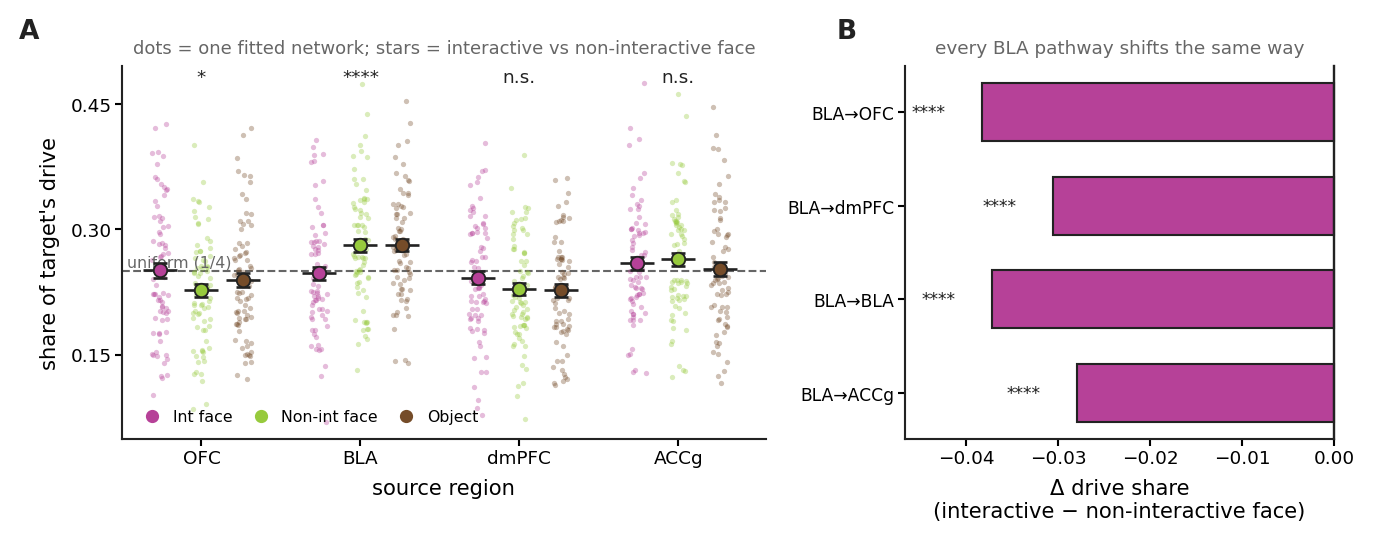

In [13]:
contribution = syn.load_stored_source_contribution(ENSEMBLE_100_SEED)
healthy_seeds = set(health.loc[~health["likely_bad_run"].astype(bool), "init_idx"])
contribution = contribution[contribution["init_idx"].isin(healthy_seeds)]

contrasts = syn.condition_contrast_by_source(contribution)
bla_pathways = syn.condition_contrast_by_pathway(contribution, source_region="bla")

display(contrasts.round(5))
show(viz.plot_condition_invariant(contribution, contrasts, bla_pathways), "fig06_condition_invariant")

In [14]:
uniform = contribution["relative_projection"].mean()
key = contrasts.set_index(["source_region", "condition_a", "condition_b"])
bla_fi_fn = key.loc[("bla", "face_interactive", "face_non_interactive")]
bla_fi_ob = key.loc[("bla", "face_interactive", "object")]
ofc_fi_fn = key.loc[("ofc", "face_interactive", "face_non_interactive")]
null_pairs = contrasts[
    (contrasts["condition_a"] == "face_non_interactive") & (contrasts["condition_b"] == "object")
]

display(Markdown(
    f"**First invariant: drive is allocated near-uniformly.** Averaged over time, every source "
    f"region supplies about {uniform:.2f} of each target's drive — a flat 1/4 split across the four "
    f"sources. No fitted network concentrates its inter-regional drive.\n\n"
    f"**Second invariant: interactive face fixations reweight that split, and only they do.** "
    f"Across {int(bla_fi_fn['n_seeds'])} independent fits, BLA's share falls during interactive face "
    f"fixations by {abs(bla_fi_fn['difference']):.3f} against non-interactive face "
    f"(Holm p = {bla_fi_fn['p_holm']:.1e}) and by {abs(bla_fi_ob['difference']):.3f} against object "
    f"(Holm p = {bla_fi_ob['p_holm']:.1e}). OFC's share rises by {ofc_fi_fn['difference']:.3f} against "
    f"non-interactive face (Holm p = {ofc_fi_fn['p_holm']:.3f}). dmPFC shifts in the same direction as "
    f"OFC but does not survive correction.\n\n"
    f"**Non-interactive face and object are indistinguishable** on every source region "
    f"(smallest Holm p = {null_pairs['p_holm'].min():.2f}), which is the control that makes the first "
    f"contrast interpretable: the effect is not a face-versus-object effect and not a generic "
    f"condition effect. It is specific to the interactive state."
))
display(bla_pathways.round(5))

**First invariant: drive is allocated near-uniformly.** Averaged over time, every source region supplies about 0.25 of each target's drive — a flat 1/4 split across the four sources. No fitted network concentrates its inter-regional drive.

**Second invariant: interactive face fixations reweight that split, and only they do.** Across 75 independent fits, BLA's share falls during interactive face fixations by 0.033 against non-interactive face (Holm p = 1.9e-06) and by 0.034 against object (Holm p = 1.3e-03). OFC's share rises by 0.024 against non-interactive face (Holm p = 0.013). dmPFC shifts in the same direction as OFC but does not survive correction.

**Non-interactive face and object are indistinguishable** on every source region (smallest Holm p = 1.00), which is the control that makes the first contrast interpretable: the effect is not a face-versus-object effect and not a generic condition effect. It is specific to the interactive state.

,pathway,mean_a,mean_b,difference,n_seeds,p_raw,p_holm
0,bla→accg,0.24977,0.27771,-0.02794,75,0.00001,0.00002
1,bla→bla,0.23633,0.27350,-0.03717,75,0.00000,0.00000
2,bla→dmpfc,0.25710,0.28765,-0.03055,75,0.00007,0.00007
3,bla→ofc,0.24522,0.28346,-0.03824,75,0.00000,0.00000


In [15]:
directions = bla_pathways["difference"] < 0
display(Markdown(
    f"**And it is a whole-region shift, not a pathway.** BLA's share falls into "
    f"{int(directions.sum())} of {len(bla_pathways)} target regions, every one of them significant "
    f"after Holm correction (largest p = {bla_pathways['p_holm'].max():.1e}), with differences "
    f"between {bla_pathways['difference'].min():.3f} and {bla_pathways['difference'].max():.3f}. "
    f"Whatever changes during interactive face fixations changes BLA's contribution to the network "
    f"as a whole."
))

**And it is a whole-region shift, not a pathway.** BLA's share falls into 4 of 4 target regions, every one of them significant after Holm correction (largest p = 7.0e-05), with differences between -0.038 and -0.028. Whatever changes during interactive face fixations changes BLA's contribution to the network as a whole.

## 7. Is the low-rank channel itself invariant?

Section 5 asked whether seeds agree on *how much* drive flows between regions. This asks
whether they agree on *what* flows: the identity of the three dimensions each pathway is
squeezed through.

A rank-3 block is $LR$. $L$ selects what is read out of the source's state; $R$ selects
where it is written into the target. Both live in hidden-unit coordinates, which are
arbitrary across seeds, so each is mapped into the relevant region's **PC space** — fixed
by the data, therefore shared by every fit — before any comparison. Two subspaces are
compared by the mean cosine of their principal angles.

Two references are needed. The first is chance: two arbitrary 3-D subspaces of a 42-D
space are not orthogonal, so an absolute alignment near 0.22 means nothing. The second is
sharper and is the test that matters — is a pathway's channel more like *itself* in
another seed than like a *different* pathway in that seed? If not, channel identity is
not recovered at all.

,kind,mean_matched,mean_mismatched,difference,n_matched,n_mismatched,mannwhitney_u,p_one_sided
0,write,0.2842,0.2838,0.0004,1080,2160,1181592.0,0.2725
1,read,0.3086,0.3144,-0.0057,1080,2160,1111612.0,0.9855


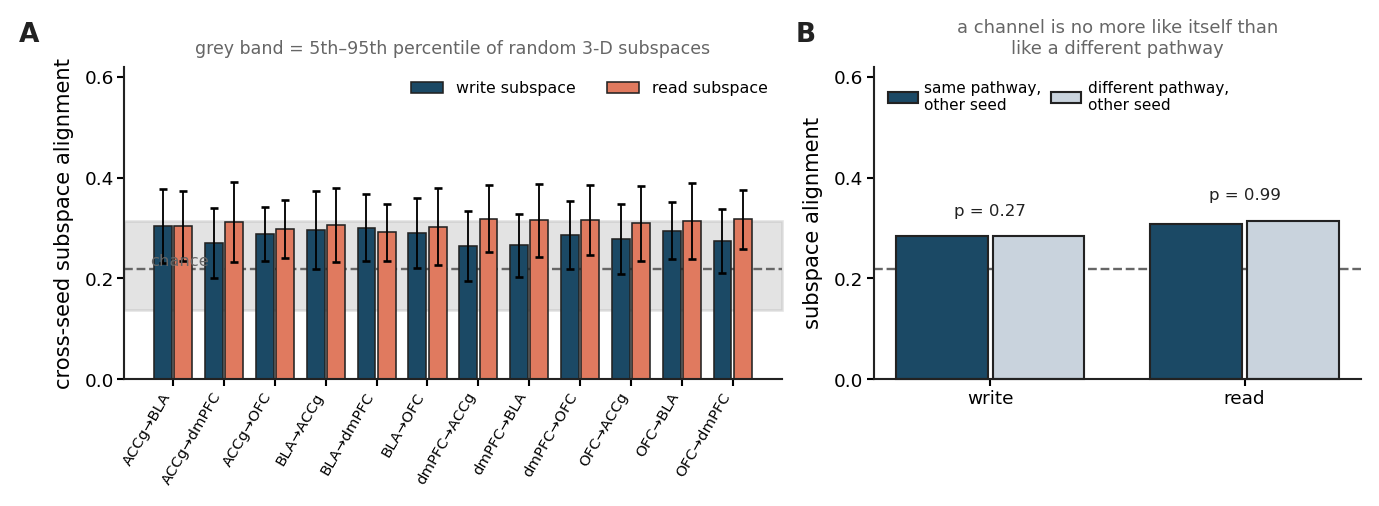

In [16]:
rank_table = syn.load_ensemble_model_rank(ENSEMBLE_RANK_3)
subspaces_by_seed = {
    int(row["init_idx"]): syn.channel_subspaces(Path(row["run_dir"]))
    for _, row in rank_table.iterrows()
}
channel_rank = subspaces_by_seed[next(iter(subspaces_by_seed))].rank

pathway_alignment = syn.channel_consistency_across_seeds(subspaces_by_seed)
identity = syn.channel_identity_test(subspaces_by_seed)
null_draws = syn.random_subspace_alignment_null(ambient_dim=42, rank=channel_rank, n_draws=2000)

display(identity.round(4))
show(viz.plot_channel_identity(pathway_alignment, identity, null_draws), "fig07_channel_identity")

In [17]:
null_mean = float(np.mean(null_draws))
null_p95 = float(np.percentile(null_draws, 95))
above_chance = int((pathway_alignment["mean_alignment"] > null_p95).sum())

display(Markdown(
    f"**The channels are not identifiable.** Cross-seed alignment averages "
    f"{pathway_alignment['mean_alignment'].mean():.3f} against a chance level of {null_mean:.3f} "
    f"(95th percentile {null_p95:.3f}); {above_chance} of {len(pathway_alignment)} "
    f"pathway x direction combinations clear that percentile.\n\n"
    f"**And what little sits above chance is not pathway-specific.** A pathway's channel is no more "
    f"similar to itself in another seed than to a different pathway in that seed — "
    f"write subspaces {identity.loc[0, 'mean_matched']:.3f} matched against "
    f"{identity.loc[0, 'mean_mismatched']:.3f} mismatched (p = {identity.loc[0, 'p_one_sided']:.2f}), "
    f"read subspaces {identity.loc[1, 'mean_matched']:.3f} against "
    f"{identity.loc[1, 'mean_mismatched']:.3f} (p = {identity.loc[1, 'p_one_sided']:.2f}).\n\n"
    f"The rank-sum p-value here is *anti-conservative* — each subspace enters many pairings, so the "
    f"comparisons are not independent and the test over-rejects under the null. That direction only "
    f"strengthens a negative finding: a test that rejects too easily and still finds nothing is "
    f"strong evidence of no effect. The matched-minus-mismatched difference, "
    f"{identity['difference'].abs().max():.3f} at its largest, is the number to read.\n\n"
    f"This is a negative result and a clean one. Ten seeds is a small ensemble, so it is possible "
    f"that a larger one would find a weak effect — but a weak effect is not what a mechanistic claim "
    f"about a three-dimensional communication channel needs. As it stands, the rank-3 bottleneck "
    f"constrains *how much* passes between regions without pinning down *what* passes."
))

**The channels are not identifiable.** Cross-seed alignment averages 0.296 against a chance level of 0.218 (95th percentile 0.313); 5 of 24 pathway x direction combinations clear that percentile.

**And what little sits above chance is not pathway-specific.** A pathway's channel is no more similar to itself in another seed than to a different pathway in that seed — write subspaces 0.284 matched against 0.284 mismatched (p = 0.27), read subspaces 0.309 against 0.314 (p = 0.99).

The rank-sum p-value here is *anti-conservative* — each subspace enters many pairings, so the comparisons are not independent and the test over-rejects under the null. That direction only strengthens a negative finding: a test that rejects too easily and still finds nothing is strong evidence of no effect. The matched-minus-mismatched difference, 0.006 at its largest, is the number to read.

This is a negative result and a clean one. Ten seeds is a small ensemble, so it is possible that a larger one would find a weak effect — but a weak effect is not what a mechanistic claim about a three-dimensional communication channel needs. As it stands, the rank-3 bottleneck constrains *how much* passes between regions without pinning down *what* passes.

## 8. What we can infer

Reading Sections 2–7 together, three claims are safe, two are suggestive, and one
question the project thought it had answered is still open.

**Safe.**

1. **Inter-regional coupling is load-bearing; dense within-region recurrence is not.**
   A model with only internal blocks plateaus around $R^2$ 0.95 while both coupled
   architectures exceed 0.99, and restricting internal coupling to a diagonal costs
   almost nothing. Whatever these four areas are doing during fixation, they are not
   doing it independently.

2. **Three dimensions per pathway are enough.** An explicit rank-3 constraint reaches
   the same quality as unconstrained full-rank coupling. The unconstrained fit's broad
   singular spectrum was slack rather than signal. The qualification is that the entire
   rank-1-to-rank-3 difference is invisible in firing-rate space, so "three dimensions"
   is a statement about the PC-space objective, not yet about the neural data.

3. **A well-fitting mRNN does not identify a circuit.** Independent fits of the same
   model to the same data reach the same loss and route the drive differently — on
   current magnitude, on relative contribution, on latent geometry, and (Section 7) on
   the identity of the low-rank channels themselves. This is the single most important
   thing the modelling has established, and it is a constraint on interpretation rather
   than a result about the brain. Any claim of the form "region A drives region B" read
   off one fit is a claim about that fit.

**Suggestive, and worth pursuing.**

4. **Interactive face fixations are what the coupling is for.** Removing inter-regional
   blocks costs several times more $R^2$ during interactive face fixations than during
   either other condition, in every region, and the intact model finds that condition
   hardest. One seed per architecture, so this needs the ensemble.

5. **BLA's contribution to the network drops during interactive face fixations, and
   this survives the ensemble.** Across 75 independent fits, paired within seed, BLA's
   share of every target region's drive falls during interactive face fixations while
   OFC's rises; non-interactive face and object are indistinguishable throughout. This
   is the one circuit-level statement in the whole analysis that is a property of the
   *data* rather than of a particular fit, because it is the direction every fit agrees
   on even while disagreeing about everything else. It has not yet been shown under the
   bottleneck, and the 3-D-bottleneck ensemble is too small (n = 10) to test it.

**Reopened.**

6. **How many units per region are needed is not known.** The sweep varied the learning
   rate together with width, and at matched width and iterations the learning rate
   accounts for the entire effect. What the fits do show is that 50 units per region is
   *sufficient*. Whether 20 would do has not been tested.

**How this sits with the population-geometry chapter.** That chapter found the
interactive-face state to be the compact, low-dimensional one in all four regions. Points
4 and 5 give that a mechanistic reading: a compact state the population enters from a
*redistributed* drive, with BLA stepping back and frontal areas stepping forward, rather
than one each region generates on its own. That is the throughline the chapter should be
built around — and it is the one that most needs the runs in Section 9.

## 9. What still has to be tested

Ordered by what blocks the chapter. G1 and G2 gate almost everything else.

| | Gap | Why it blocks | What it takes |
|---|---|---|---|
| **G1** | **Iteration-matched bottleneck ensembles.** 100 seeds at ranks 1, 3 and 5, all at 250k iterations, everything else identical. | The headline consistency claim (§5) currently confounds rank with training length. Also delivers G8 for free. | One cluster array job. The largest single item, launch first. |
| **G2** | **Best-iterate checkpointing.** | ~⅓ of saved checkpoints are worse than their own run's best loss (§1a). Every architecture comparison inherits this. | A code change in the training loop, plus a re-run of anything compared in the chapter. |
| **G3** | **Ensemble the architecture comparison.** 20+ seeds per architecture at 50 units. | §3 and inference 4 rest on one seed each. | Second cluster job. |
| **G4** | **Capacity-matched architectures**, 50 / 57 / 90 units. | `within_region` has 40% of `full`'s parameters, so its worse fit is confounded with its size. Sizes already solved for; never trained. | Three runs. |
| **G5** | **A clean hidden-unit sweep** at fixed learning rate (1e-3) and fixed iterations, 10–60 units. | §2 — the capacity question is currently unanswered. | One small sweep; cheap. |
| **G6** | **Held-out data.** Train with `post_fixation_loss_weight = 0.0` and score the post-fixation half the model must generate by rolling its own dynamics forward. | Every number in this notebook is in-sample on a model with parameters ≈ observations. | No new code; one run per architecture of interest. |
| **G7** | **Refit ranks 10/20/30 at 100k iterations.** | §4 can only be read in one block. | Three runs. |
| **G8** | **The condition contrast under the bottleneck.** | §6 is established only for the unbottlenecked ensemble. A first pass over the 10 rank-3 seeds reproduces the direction of every significant effect, but n = 10 is underpowered. | Falls out of G1. |
| **G9** | **Dynamical-systems characterisation.** Fixed points and Jacobian eigenspectra per condition; whether the three conditions share a basin; the slow manifold; whether the interactive-face state is a distinct attractor. | Nothing in the analysis yet describes the model *as a dynamical system*. This is the mechanistic payoff and it is unstarted. | New `src/` analysis, run over the G1 ensemble. |
| **G10** | **Extend the channel-identity test.** §7 is a negative result on 10 seeds; repeat on the 100-seed rank-3 ensemble, and ask whether the *union* of the three channels across a pathway is more stable than each channel individually. | Decides whether §7 is "not identifiable" or "identifiable but underpowered". | Falls out of G1. |

### Recommended order

1. **G2** — a code change; everything downstream depends on it.
2. **G1** — the big cluster job; launch early. Gives G8 and G10.
3. **G5** — cheap, and closes the one question that has been reopened.
4. **G3 + G4** — second cluster job.
5. **G9** — new analysis code, on the G1 ensemble.
6. **G6**, **G7** — the remaining cleanup runs.

### Caveats the chapter has to carry

- **In-sample only** until G6 runs, on a model whose free parameters are of the same
  order as the dataset's 50,400 numbers. No parameter-counting criterion (AIC, BIC,
  adjusted $R^2$, nested F-tests) is interpretable in that regime; they belong in the
  text as a caveat, never as a selection rule.
- **The model is finely tuned, not robust.** In the trained `full` network a 5%
  attenuation of any recurrent block costs several points of $R^2$ and 20% destroys the
  fit. Perturbation results describe the fit, not the brain.
- **Object fixations are not matched for interactive state**, so part of any
  face-versus-object difference is context mixing. The interactive-versus-non-interactive
  face contrast in §6 does not have this problem, which is one more reason it carries
  more weight than the face/object comparisons.
- **A well-fitting mRNN is a hypothesis generator about routing, not a measurement of
  it.** Section 5 is the evidence for that statement, and it should be stated in the
  Discussion rather than buried in a supplement.